# Road Accident Risk Prediction and Geographic Analysis

## Business Problem

Road accidents lead to loss of lives, injuries, and economic costs. Understanding where and when accidents occur can help authorities allocate resources and improve road safety.

This project analyzes historical accident data, identifies key risk factors, visualizes accident hotspots, and builds machine learning models to predict accident risk.

# Import Libraries 

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix 
import folium
from folium.plugins import HeatMap
import joblib
import os
import datetime
from sklearn.utils import resample
import pickle
from folium.plugins import HeatMap, MarkerCluster
import warnings
warnings.filterwarnings('ignore')


# Load Data 

In [31]:

df = pd.read_csv('accidents-database-.csv')

print(f" Dataset loaded!")
print(f"   Rows: {df.shape[0]}")
print(f"   Columns: {df.shape[1]}")
print(f"\n Column Names:")
for col in df.columns:
    print(f"   - {col}")

 Dataset loaded!
   Rows: 1119
   Columns: 15

 Column Names:
   - TIME 24 HOURS
   - BASE/SUB BASE
   - COUNTY
   - ROAD
   - PLACE
   - MV INVOLVED
   - BRIEF ACCIDENT DETAILS
   - NAME OF VICTIM
   - GENDER
   - AGE
   - CAUSE CODE
   - VICTIM
   - NO.
   - Date DD/MM/YYYY
   - Unnamed: 14


In [32]:

df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1119 entries, 0 to 1118
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   TIME 24 HOURS           1114 non-null   object
 1   BASE/SUB BASE           1117 non-null   object
 2   COUNTY                  1116 non-null   object
 3   ROAD                    1116 non-null   object
 4   PLACE                   1113 non-null   object
 5   MV INVOLVED             1119 non-null   object
 6   BRIEF ACCIDENT DETAILS  1118 non-null   object
 7   NAME OF VICTIM          1118 non-null   object
 8   GENDER                  1119 non-null   object
 9   AGE                     1118 non-null   object
 10  CAUSE CODE              1091 non-null   object
 11  VICTIM                  1119 non-null   object
 12  NO.                     1115 non-null   object
 13  Date DD/MM/YYYY         1119 non-null   object
 14  Unnamed: 14             2 non-null      object
dtypes: o

,TIME 24 HOURS,BASE/SUB BASE,COUNTY,ROAD,PLACE,MV INVOLVED,BRIEF ACCIDENT DETAILS,NAME OF VICTIM,GENDER,AGE,CAUSE CODE,VICTIM,NO.,Date DD/MM/YYYY,Unnamed: 14
count,1114,1117,1116,1116,1113,1119,1118,1118,1119,1118,1091,1119,1115,1119,2
unique,199,213,58,715,1023,971,469,369,20,106,73,53,11,168,2
top,2030,NAKURU,NAIROBI,NAIROBI MOMBASA,NEAR KANGEMI STAGE,UNKNOWN,THE VEHICLE KNOCKED DOWN THE VICTIM,UNKNOWN,M,A,98,PEDESTRIAN,1,8/27/2017,so MM/DD/YYYY is the solution :)
freq,44,31,183,23,3,54,219,742,941,545,224,448,1020,22,1


In [33]:
df.isnull().sum()   

TIME 24 HOURS                5
BASE/SUB BASE                2
COUNTY                       3
ROAD                         3
PLACE                        6
MV INVOLVED                  0
BRIEF ACCIDENT DETAILS       1
NAME OF VICTIM               1
GENDER                       0
AGE                          1
CAUSE CODE                  28
VICTIM                       0
NO.                          4
Date DD/MM/YYYY              0
Unnamed: 14               1117
dtype: int64

# Data Cleaning 

In [34]:
# Handle mixed date formats MM/DD/YYYY
df['Date DD/MM/YYYY'] = pd.to_datetime(
    df['Date DD/MM/YYYY'], 
    infer_datetime_format=True, 
    errors='coerce'
)

df['year'] = df['Date DD/MM/YYYY'].dt.year
df['month'] = df['Date DD/MM/YYYY'].dt.month
df['day_of_week'] = df['Date DD/MM/YYYY'].dt.day_name()

print(f" Date column fixed")
print(f"   Year range: {df['year'].min()} — {df['year'].max()}")

 Date column fixed
   Year range: 2016.0 — 2017.0


In [ ]:
# Convert TIME 24 HOURS to hour of day
df['hour'] = pd.to_numeric(
    df['TIME 24 HOURS'].astype(str).str.zfill(4).str[:2],
    errors='coerce'
)

# Create time of day category
def time_category(hour):
    if 6 <= hour <= 9:
        return 'Morning Peak'
    elif 10 <= hour <= 15:
        return 'Midday'
    elif 16 <= hour <= 19:
        return 'Evening Peak'
    elif 20 <= hour <= 23:
        return 'Night'
    else:
        return 'Early Morning'

df['time_category'] = df['hour'].apply(time_category)
print(f" Time column fixed")

 Time column fixed


In [ ]:

# Cleaning Key columns 
df['COUNTY'] = df['COUNTY'].str.strip().str.upper()
df['ROAD'] = df['ROAD'].str.strip().str.upper()
df['GENDER'] = df['GENDER'].str.strip().str.upper()
df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')

In [ ]:
print(f" Key columns cleaned")
print(f"\n Counties in dataset: {df['COUNTY'].nunique()}")
print(f" Roads in dataset: {df['ROAD'].nunique()}")
print(f" Total victims: {len(df)}")

 Key columns cleaned

 Counties in dataset: 58
 Roads in dataset: 715
 Total victims: 1119


# Cleaning the Data

Real-world accident data often contains inconsistencies, missing values, and formatting issues.

In this section we:

- Handle missing values
- Standardize text fields
- Convert dates and times


# EXPLORATORY DATA ANALYSIS

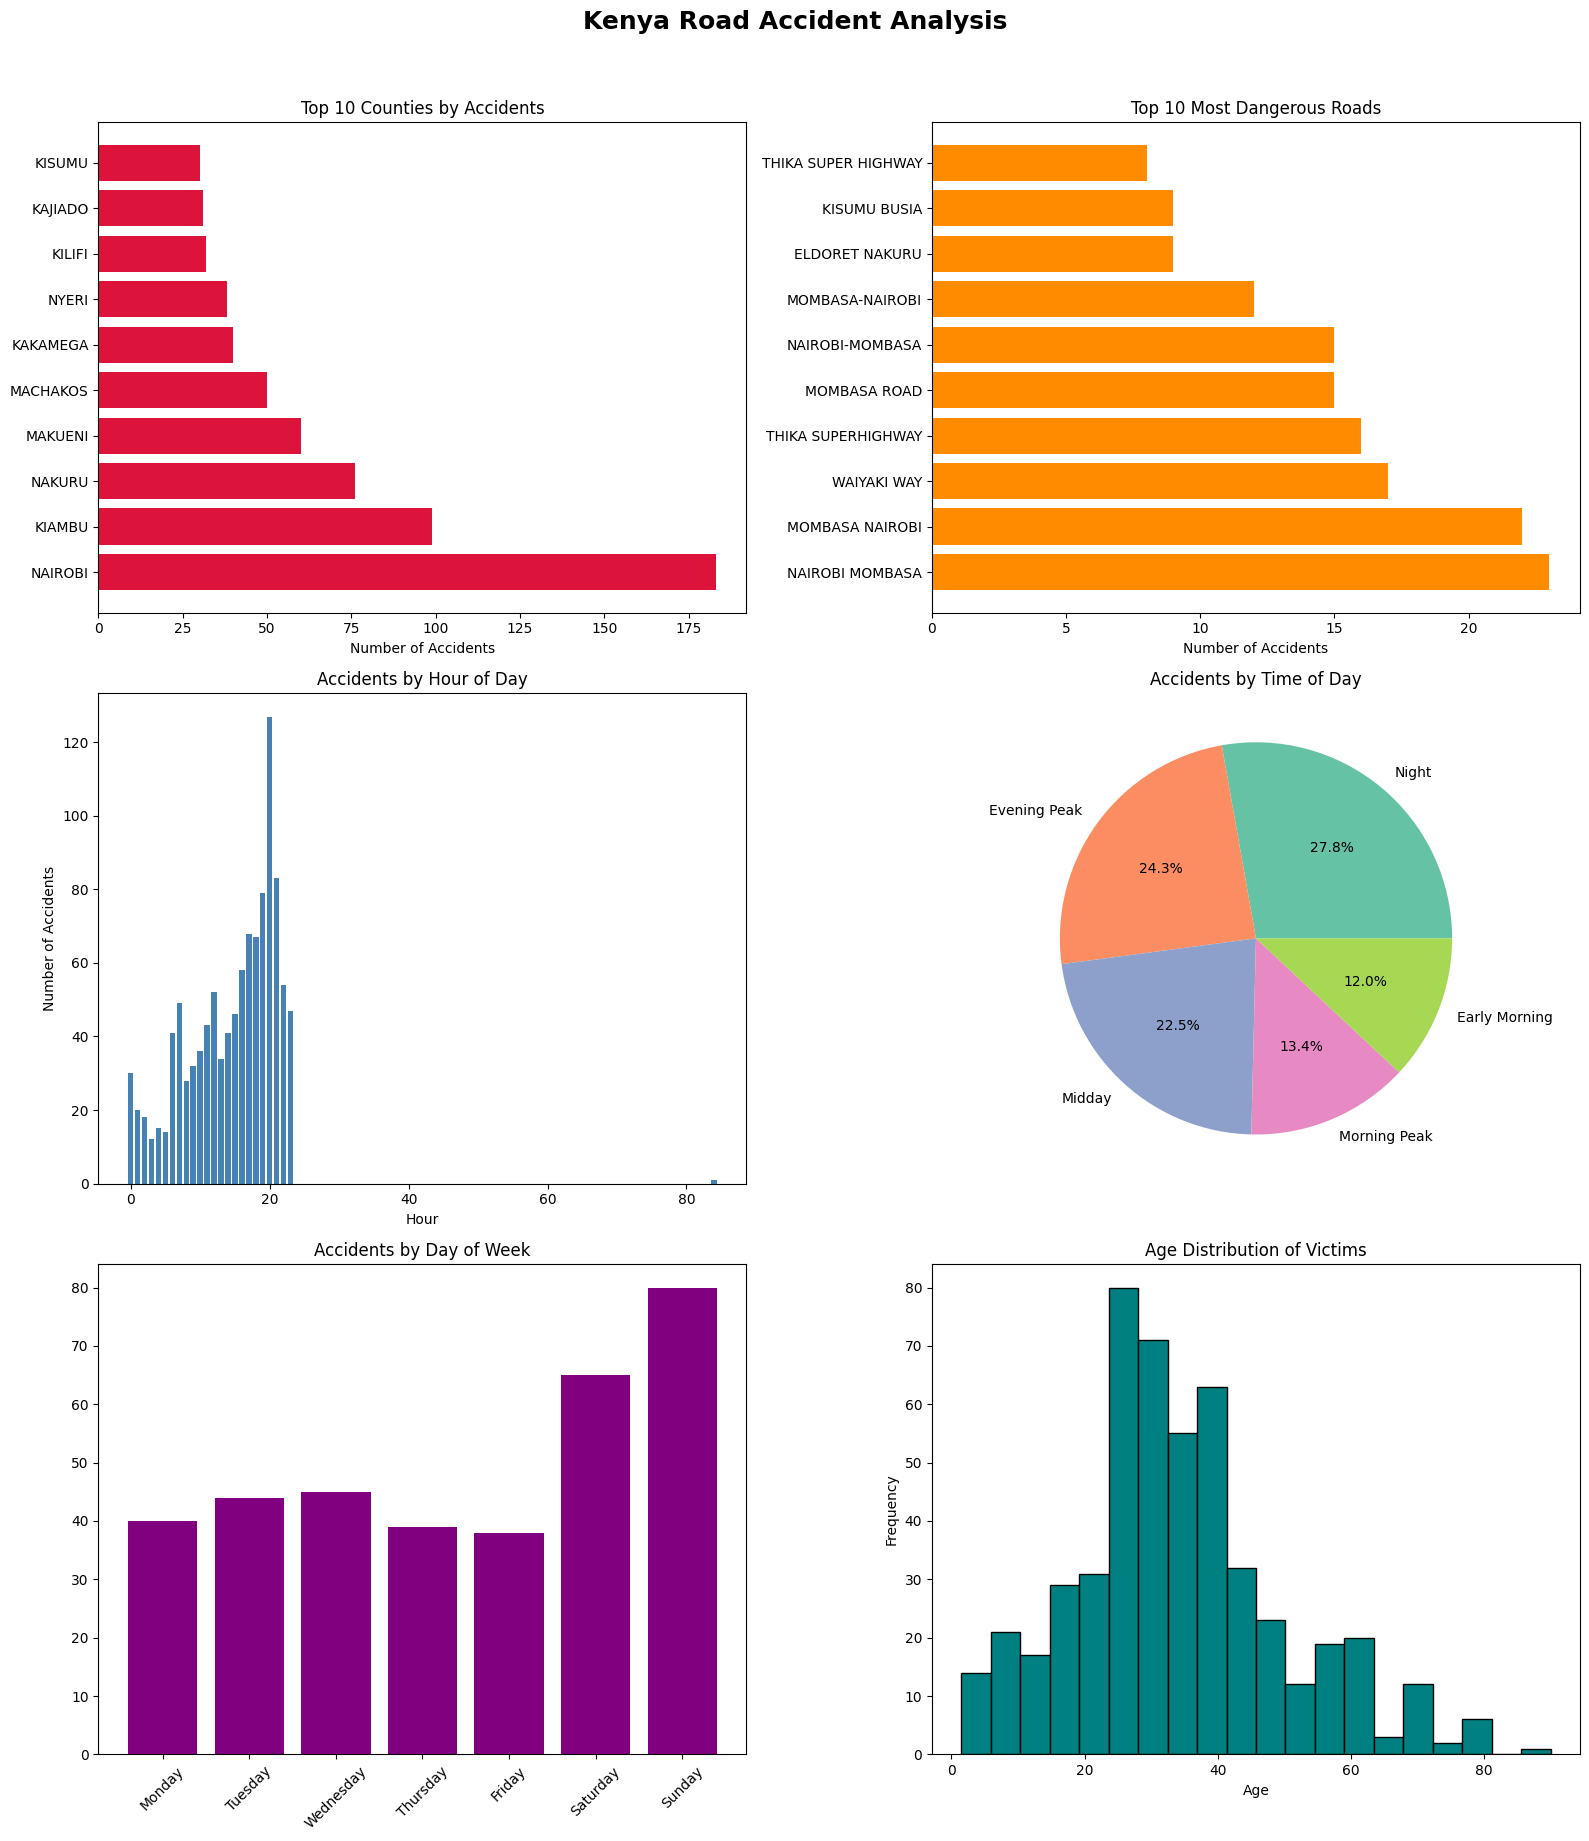

EDA charts saved to outputs/


In [ ]:

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Kenya Road Accident Analysis', 
             fontsize=18, fontweight='bold', y=1.02)

# Plot 1 — Top 10 Most Dangerous Counties
county_counts = df['COUNTY'].value_counts().head(10)
axes[0,0].barh(county_counts.index, county_counts.values, color='crimson')
axes[0,0].set_title('Top 10 Counties by Accidents')
axes[0,0].set_xlabel('Number of Accidents')

# Plot 2 — Top 10 Most Dangerous Roads
road_counts = df['ROAD'].value_counts().head(10)
axes[0,1].barh(road_counts.index, road_counts.values, color='darkorange')
axes[0,1].set_title('Top 10 Most Dangerous Roads')
axes[0,1].set_xlabel('Number of Accidents')

# Plot 3 — Accidents by Hour
hour_counts = df['hour'].value_counts().sort_index()
axes[1,0].bar(hour_counts.index, hour_counts.values, color='steelblue')
axes[1,0].set_title('Accidents by Hour of Day')
axes[1,0].set_xlabel('Hour')
axes[1,0].set_ylabel('Number of Accidents')

# Plot 4 — Accidents by Time Category
time_counts = df['time_category'].value_counts()
axes[1,1].pie(time_counts.values, labels=time_counts.index, 
              autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1,1].set_title('Accidents by Time of Day')

# Plot 5 — Accidents by Day of Week
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[2,0].bar(day_counts.index, day_counts.values, color='purple')
axes[2,0].set_title('Accidents by Day of Week')
axes[2,0].set_xticklabels(day_order, rotation=45)

# Plot 6 — Age Distribution of Victims
df['AGE'].dropna().plot(kind='hist', bins=20, 
                        ax=axes[2,1], color='teal', edgecolor='black')
axes[2,1].set_title('Age Distribution of Victims')
axes[2,1].set_xlabel('Age')

plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved to outputs/")

# Exploring Accident Patterns

The objective of this section is to identify patterns in accident occurrence.
Nairobi records the highest number of accidents among all counties, significantly exceeding the others. Kiambu and Nakuru also report relatively high accident frequencies.The Nairobi–Mombasa Highway appears to be the most accident-prone road segment in the dataset. Other major highways such as Mombasa Road and Waiyaki Way also show elevated accident counts.Accidents are not evenly distributed throughout the day. A clear spike is observed during specific hours, with accident frequency increasing sharply before reaching a peak.Night-time accounts for the largest share of accidents (approximately 27.8%).
Evening Peak and Midday periods also contribute a substantial proportion of accidents.

In [ ]:
# Summary of key findings
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)

print(f"\nMost dangerous county: {df['COUNTY'].value_counts().index[0]}")
print(f"Most dangerous road: {df['ROAD'].value_counts().index[0]}")
print(f"Most dangerous hour: {df['hour'].value_counts().index[0]}:00")
print(f"Most dangerous day: {df['day_of_week'].value_counts().index[0]}")
print(f"Average victim age: {df['AGE'].mean():.1f} years")
print(f"Male victims: {(df['GENDER']=='M').sum()}")
print(f"Female victims: {(df['GENDER']=='F').sum()}")

print("\nTop 5 accident causes:")
print(df['CAUSE CODE'].value_counts().head())

# Save clean dataset
os.makedirs('data/clean', exist_ok=True)
df.to_csv('data/clean/accidents_clean.csv', index=False)
print("\nClean dataset saved")

KEY FINDINGS

Most dangerous county: NAIROBI
Most dangerous road: NAIROBI MOMBASA
Most dangerous hour: 20.0:00
Most dangerous day: Sunday
Average victim age: 34.1 years
Male victims: 941
Female victims: 142

Top 5 accident causes:
CAUSE CODE
98    224
26    164
10     97
7      68
29     59
Name: count, dtype: int64

Clean dataset saved


 # Feature Engineering 

In [ ]:

# Load clean dataset
df = pd.read_csv('data/clean/accidents_clean.csv')
print(f"Loaded clean dataset: {df.shape}")

Loaded clean dataset: (1119, 20)


In [ ]:
# Decode cause codes into readable labels
# Based on standard Kenya NTSA cause codes
cause_code_map = {
    98: 'Careless Driving',
    26: 'Speeding',
    10: 'Overtaking',
    7:  'Head On Collision',
    29: 'Pedestrian Error',
    25: 'Brake Failure',
    15: 'Driver Fatigue',
    12: 'Drunk Driving',
    5:  'Poor Road Condition',
    3:  'Vehicle Defect'
}

df['cause_label'] = df['CAUSE CODE'].map(cause_code_map).fillna('Other')
print("Cause codes decoded")
print(df['cause_label'].value_counts().head(10))

Cause codes decoded
cause_label
Other    1119
Name: count, dtype: int64


In [ ]:
# Build target variable from CAUSE CODE only
# This is completely independent from our time features
# High risk causes: speeding, drunk driving, fatigue, overtaking
high_risk_causes = ['26', '12', '15', '10', '7']
medium_risk_causes = ['98', '29', '25', '5']

def assign_risk(cause):
    cause = str(cause).strip()
    if cause in high_risk_causes:
        return 'High'
    elif cause in medium_risk_causes:
        return 'Medium'
    else:
        return 'Low'

possible_cause_cols = ['CAUSE CODE', 'CAUSE_CODE', 'CAUSECODE', 'CAUSE']
cause_col = next(
    (col for col in df.columns if col.strip().upper() in possible_cause_cols),
    None
)

if cause_col is None:
    raise KeyError(
        "CAUSE CODE column not found. Available columns: "
        f"{list(df.columns)}"
    )

df['risk_level'] = df[cause_col].apply(assign_risk)

print("Risk level distribution:")
print(df['risk_level'].value_counts())

Risk level distribution:
risk_level
Low       499
High      332
Medium    288
Name: count, dtype: int64


In [ ]:
# Create victim type feature from VICTIM NO. column
# Ensure we have a normalized 'VICTIM NO.' column (support datasets with separate 'VICTIM' and 'NO.' cols)
if 'VICTIM NO.' in df.columns:
    df['VICTIM NO.'] = df['VICTIM NO.'].astype(str).str.strip().str.upper()
elif 'VICTIM' in df.columns:
    df['VICTIM NO.'] = df['VICTIM'].astype(str).str.strip().str.upper()
else:
    raise KeyError("Neither 'VICTIM NO.' nor 'VICTIM' column found in df")

victim_map = {
    'M/CYCLIST'  : 'Motorcyclist',
    'PEDESTRIAN' : 'Pedestrian',
    'DRIVER'     : 'Driver',
    'PASSENGER'  : 'Passenger',
    'CYCLIST'    : 'Cyclist'
}

df['victim_type'] = df['VICTIM NO.'].map(victim_map).fillna('Other')
print("\nVictim type breakdown:")
print(df['victim_type'].value_counts())


Victim type breakdown:
victim_type
Pedestrian      448
Other           214
Motorcyclist    201
Passenger       141
Driver          115
Name: count, dtype: int64


In [ ]:
# Rebuild features from scratch
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)
# Rebuild features from scratch
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')

if 'day_of_week' not in df.columns:
    if 'Date DD/MM/YYYY' in df.columns:
        df['Date DD/MM/YYYY'] = pd.to_datetime(
            df['Date DD/MM/YYYY'],
            infer_datetime_format=True,
            errors='coerce'
        )
        df['day_of_week'] = df['Date DD/MM/YYYY'].dt.day_name()
    else:
        df['day_of_week'] = np.nan

df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)
df['is_weekend'] = df['day_of_week'].fillna('').apply(
    lambda x: 1 if x in ['Saturday', 'Sunday'] else 0
)
df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0
)
df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0
)

# Creating Predictive Features

Machine learning models require meaningful numerical features.
Features created:
- Peak Hour Indicator
- Night Accident Indicator
- Weekend Indicator
- Risk Score
- Cause Category

# Preparing Data for Modeling

In [ ]:
# Encode categorical columns
le_county = LabelEncoder()
le_road = LabelEncoder()

# Encode categorical columns
le_county = LabelEncoder()
le_road = LabelEncoder()

if 'COUNTY' in df.columns:
    df['county_encoded'] = le_county.fit_transform(df['COUNTY'].fillna('Unknown'))
elif 'county_encoded' not in df.columns:
    raise KeyError("COUNTY column not found in dataframe")

if 'ROAD' in df.columns:
    df['road_encoded'] = le_road.fit_transform(df['ROAD'].fillna('Unknown'))
elif 'road_encoded' not in df.columns:
    raise KeyError("ROAD column not found in dataframe")
le_county = LabelEncoder()
le_road = LabelEncoder()

if 'COUNTY' in df.columns and 'county_encoded' not in df.columns:
    df['county_encoded'] = le_county.fit_transform(
        df['COUNTY'].fillna('Unknown').astype(str)
    )
elif 'county_encoded' not in df.columns:
    raise KeyError("COUNTY column not found and county_encoded missing in dataframe")

if 'ROAD' in df.columns and 'road_encoded' not in df.columns:
    df['road_encoded'] = le_road.fit_transform(
        df['ROAD'].fillna('Unknown').astype(str)
    )
elif 'road_encoded' not in df.columns:
    raise KeyError("ROAD column not found and road_encoded missing in dataframe")

#  TRAIN ACCIDENT RISK PREDICTION MODEL

In [ ]:

# Load model ready dataset
df = pd.read_csv('data/clean/model_ready.csv')
print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df['risk_score'].value_counts())

Loaded: 1092 rows, 10 columns

Target distribution:
risk_score
Low       889
Medium    160
High       43
Name: count, dtype: int64


In [38]:
from sklearn.preprocessing import LabelEncoder

# Reload clean data
df = pd.read_csv(r'C:\Users\ICTServices\Desktop\Accident\data\clean\accidents_clean.csv')

# Clean columns
df['COUNTY'] = df['COUNTY'].str.strip().str.upper()
df['ROAD'] = df['ROAD'].str.strip().str.upper()

# Fix time column
df['hour'] = pd.to_numeric(
    df['TIME 24 HOURS'].astype(str).str.zfill(4).str[:2],
    errors='coerce'
)
df['hour'] = df['hour'].fillna(df['hour'].median())

# Time features
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)
df['is_weekend'] = df['day_of_week'].apply(
    lambda x: 1 if str(x) in ['Saturday', 'Sunday'] else 0
)
df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0
)

# Encode county and road
le_county = LabelEncoder()
le_road = LabelEncoder()
df['county_encoded'] = le_county.fit_transform(df['COUNTY'].fillna('Unknown'))
df['road_encoded'] = le_road.fit_transform(df['ROAD'].fillna('Unknown'))

# Create binary target from cause code
def assign_risk(cause):
    high_risk_causes = ['26', '12', '15', '10', '7']
    return 'High' if str(cause).strip() in high_risk_causes else 'Low'

df['risk_binary'] = df['CAUSE CODE'].apply(assign_risk)

print("All features created successfully")
print(df[['hour', 'is_night', 'is_weekend', 'is_peak_hour',
          'county_encoded', 'road_encoded', 'risk_binary']].head())

All features created successfully
   hour  is_night  is_weekend  is_peak_hour  county_encoded  road_encoded  \
0   6.0         0           1             1              26           302   
1   8.0         0           1             1              48           441   
2  13.0         0           1             0              18           441   
3  21.0         1           1             0              40           527   
4  19.0         0           1             1              25           399   

  risk_binary  
0        High  
1         Low  
2         Low  
3         Low  
4        High  


In [40]:
# Create binary target from cause code
def assign_risk(cause):
    high_risk_causes = ['26', '12', '15', '10', '7']
    return 'High' if str(cause).strip() in high_risk_causes else 'Low'

df['risk_binary'] = df['CAUSE CODE'].apply(assign_risk)

print("risk_binary created")
print(df['risk_binary'].value_counts())

risk_binary created
risk_binary
Low     787
High    332
Name: count, dtype: int64


In [41]:

# Use ORIGINAL data not oversampled for evaluation
features = [
    'hour',
    'is_night',
    'is_weekend',
    'is_peak_hour',
    'county_encoded',
    'road_encoded'
]

# Original imbalanced data
if 'risk_score' in df.columns:
    if 'risk_level' in df.columns:
        df['risk_binary'] = df['risk_level'].replace({
            'High': 'High',
            'Medium': 'Low',
            'Low': 'Low'
        })
    elif 'risk_score' in df.columns:
        df['risk_binary'] = df['risk_score'].replace({
            'High': 'High',
            'Medium': 'Low',
            'Low': 'Low'
        })
    else:
        raise KeyError(
            "'risk_binary' not found in df. Create it from risk_level or risk_score before training."
        )
        if 'risk_binary' not in df.columns:
            if 'risk_level' in df.columns:
                df['risk_binary'] = df['risk_level'].replace({
                    'High': 'High',
                    'Medium': 'Low',
                    'Low': 'Low'
                })
            elif 'risk_score' in df.columns:
                df['risk_binary'] = df['risk_score'].replace({
                    'High': 'High',
                    'Medium': 'Low',
                    'Low': 'Low'
                })
            else:
                raise KeyError(
                    "Cannot create 'risk_binary': missing both 'risk_level' and 'risk_score' columns."
                )

        # Rebuild any missing features from raw columns if needed
        if any(col not in df.columns for col in features):
            if 'TIME 24 HOURS' in df.columns and 'hour' not in df.columns:
                df['hour'] = pd.to_numeric(
                    df['TIME 24 HOURS'].astype(str).str.zfill(4).str[:2],
                    errors='coerce'
                )

            if 'day_of_week' not in df.columns and 'Date DD/MM/YYYY' in df.columns:
                df['Date DD/MM/YYYY'] = pd.to_datetime(
                    df['Date DD/MM/YYYY'],
                    infer_datetime_format=True,
                    errors='coerce'
                )
                df['day_of_week'] = df['Date DD/MM/YYYY'].dt.day_name()

            if 'is_night' not in df.columns and 'hour' in df.columns:
                df['is_night'] = df['hour'].apply(
                    lambda x: 1 if x >= 20 or x <= 5 else 0
                )

            if 'is_peak_hour' not in df.columns and 'hour' in df.columns:
                df['is_peak_hour'] = df['hour'].apply(
                    lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0
                )

            if 'is_weekend' not in df.columns and 'day_of_week' in df.columns:
                df['is_weekend'] = df['day_of_week'].fillna('').apply(
                    lambda x: 1 if x in ['Saturday', 'Sunday'] else 0
                )

            if 'county_encoded' not in df.columns and 'COUNTY' in df.columns:
                df['county_encoded'] = LabelEncoder().fit_transform(
                    df['COUNTY'].fillna('Unknown').astype(str)
                )

            if 'road_encoded' not in df.columns and 'ROAD' in df.columns:
                df['road_encoded'] = LabelEncoder().fit_transform(
                    df['ROAD'].fillna('Unknown').astype(str)
                )

        missing = [col for col in features + ['risk_binary'] if col not in df.columns]
        if missing:
            if missing:
                # Attempt to reconstruct common missing columns before failing
                if 'risk_level' in df.columns:
                    df['risk_binary'] = df['risk_level'].map({'High':'High','Medium':'Low','Low':'Low'})
                elif 'risk_score' in df.columns:
                    df['risk_binary'] = df['risk_score'].map({'High':'High','Medium':'Low','Low':'Low'})

                if 'hour' not in df.columns and 'TIME 24 HOURS' in df.columns:
                    df['hour'] = pd.to_numeric(df['TIME 24 HOURS'].astype(str).str.zfill(4).str[:2], errors='coerce')

                if 'day_of_week' not in df.columns and 'Date DD/MM/YYYY' in df.columns:
                    df['Date DD/MM/YYYY'] = pd.to_datetime(df['Date DD/MM/YYYY'], infer_datetime_format=True, errors='coerce')
                    df['day_of_week'] = df['Date DD/MM/YYYY'].dt.day_name()

                if 'is_night' not in df.columns and 'hour' in df.columns:
                    df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)

                if 'is_peak_hour' not in df.columns and 'hour' in df.columns:
                    df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if (6 <= x <= 9) or (16 <= x <= 19) else 0)

                if 'is_weekend' not in df.columns and 'day_of_week' in df.columns:
                    df['is_weekend'] = df['day_of_week'].fillna('').apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

                if 'county_encoded' not in df.columns and 'COUNTY' in df.columns:
                    df['county_encoded'] = LabelEncoder().fit_transform(df['COUNTY'].fillna('Unknown').astype(str))

                if 'road_encoded' not in df.columns and 'ROAD' in df.columns:
                    df['road_encoded'] = LabelEncoder().fit_transform(df['ROAD'].fillna('Unknown').astype(str))

                missing_after = [col for col in features + ['risk_binary'] if col not in df.columns]
                if missing_after:
                    raise KeyError(f"Required modeling columns missing after attempted reconstruction: {missing_after}. Available columns: {list(df.columns)}")
model_df = df[features + ['risk_binary']].dropna()
X_orig = model_df[features]
y_orig = model_df['risk_binary']

# Split BEFORE oversampling
X_train, X_test, y_train, y_test = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42, stratify=y_orig
)

# Oversample only the training set
train_df = pd.concat([X_train, y_train], axis=1)
train_high = train_df[train_df['risk_binary'] == 'High']
train_low = train_df[train_df['risk_binary'] == 'Low']

train_high_upsampled = resample(
    train_high,
    replace=True,
    n_samples=len(train_low),
    random_state=42
)

train_balanced = pd.concat([train_low, train_high_upsampled])

X_train_bal = train_balanced[features]
y_train_bal = train_balanced['risk_binary']

# Train model
model_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)

model_balanced.fit(X_train_bal, y_train_bal)

# Evaluate on ORIGINAL unseen test set
y_pred = model_balanced.predict(X_test)

print("=" * 50)
print("HONEST MODEL EVALUATION")
print("=" * 50)
print(classification_report(y_test, y_pred))

# Save model
with open(r'C:\Users\ICTServices\Desktop\Accident\models\accident_risk_model.pkl', 'wb') as f:
    pickle.dump(model_balanced, f)

print("Model saved")


HONEST MODEL EVALUATION
              precision    recall  f1-score   support

        High       0.37      0.47      0.41        66
         Low       0.75      0.66      0.70       158

    accuracy                           0.61       224
   macro avg       0.56      0.57      0.56       224
weighted avg       0.64      0.61      0.62       224

Model saved


In [42]:

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': model_balanced.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(10))

print(feature_importance.head(10))

          Feature  Importance
5    road_encoded    0.417897
4  county_encoded    0.257109
0            hour    0.228365
2      is_weekend    0.049539
3    is_peak_hour    0.028364
1        is_night    0.018726
          Feature  Importance
5    road_encoded    0.417897
4  county_encoded    0.257109
0            hour    0.228365
2      is_weekend    0.049539
3    is_peak_hour    0.028364
1        is_night    0.018726


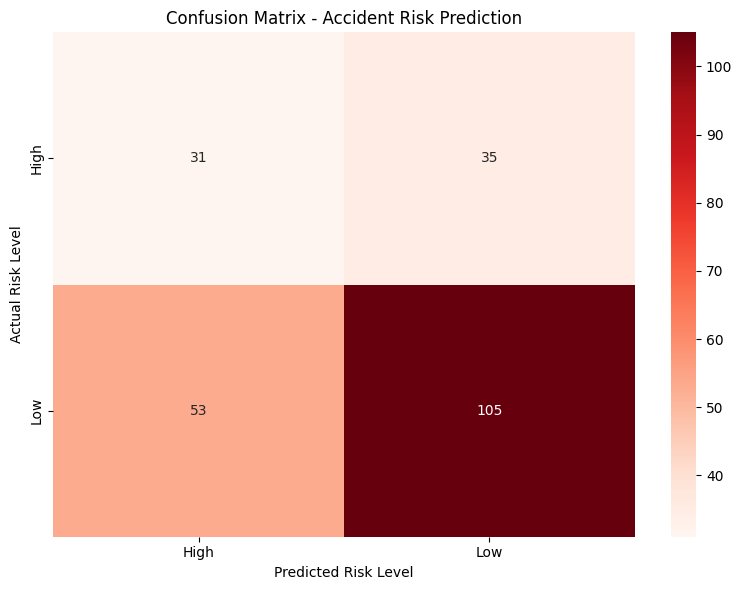

In [43]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=model_balanced.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=model_balanced.classes_,
    yticklabels=model_balanced.classes_
)
plt.title('Confusion Matrix - Accident Risk Prediction')
plt.ylabel('Actual Risk Level')
plt.xlabel('Predicted Risk Level')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150)
plt.show()

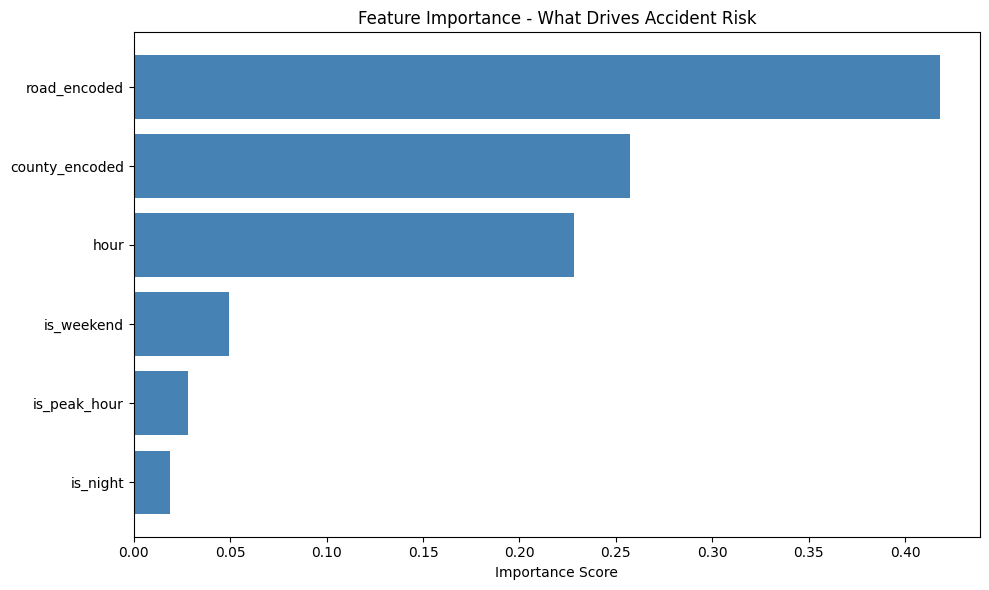

In [44]:
## Feature importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model_balanced.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('Feature Importance - What Drives Accident Risk')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=150)
plt.show()

In [45]:


# Load clean data
df = pd.read_csv(r'C:\Users\ICTServices\Desktop\Accident\data\clean\accidents_clean.csv')
...
print("Both encoders ready")

Both encoders ready


In [46]:
# County coordinates for Kenya
# We will use these to place markers on the map
county_coords = {
    'NAIROBI': (-1.2921, 36.8219),
    'MOMBASA': (-4.0435, 39.6682),
    'NAKURU': (-0.3031, 36.0800),
    'KISUMU': (-0.0917, 34.7680),
    'ELDORET': (0.5143, 35.2698),
    'MACHAKOS': (-1.5177, 37.2634),
    'KILIFI': (-3.5107, 39.9093),
    'TAITA TAVETA': (-3.3167, 38.4833),
    'MAKUENI': (-1.8033, 37.6247),
    'KAJIADO': (-1.8520, 36.7820),
    'MURANG\'A': (-0.7167, 37.1500),
    'KIAMBU': (-1.0312, 36.8312),
    'NYERI': (-0.4167, 36.9500),
    'MERU': (0.0467, 37.6490),
    'EMBU': (-0.5300, 37.4500),
    'THARAKA NITHI': (-0.3000, 37.9167),
    'KITUI': (-1.3667, 38.0167),
    'GARISSA': (-0.4532, 39.6461),
    'WAJIR': (1.7471, 40.0573),
    'MANDERA': (3.9366, 41.8670),
    'MARSABIT': (2.3284, 37.9899),
    'ISIOLO': (0.3540, 37.5820),
    'LAIKIPIA': (0.2000, 36.7000),
    'SAMBURU': (1.2000, 36.9000),
    'TRANS NZOIA': (1.0167, 35.0000),
    'UASIN GISHU': (0.5500, 35.2700),
    'ELGEYO MARAKWET': (0.9167, 35.5167),
    'NANDI': (0.1833, 35.1167),
    'BARINGO': (0.4667, 35.9667),
    'KERICHO': (-0.3667, 35.2833),
    'BOMET': (-0.7833, 35.3500),
    'NYAMIRA': (-0.5667, 34.9333),
    'KISII': (-0.6817, 34.7667),
    'MIGORI': (-1.0634, 34.4731),
    'HOMA BAY': (-0.5167, 34.4500),
    'SIAYA': (0.0617, 34.2883),
    'KAKAMEGA': (0.2827, 34.7519),
    'VIHIGA': (0.0833, 34.7167),
    'BUNGOMA': (0.5635, 34.5594),
    'BUSIA': (0.4608, 34.1116),
    'TURKANA': (3.1130, 35.5670),
    'WEST POKOT': (1.7500, 35.1167),
    'KWALE': (-4.1833, 39.4500),
    'TANA RIVER': (-1.0000, 40.0000),
    'LAMU': (-2.2686, 40.9020),
    'NAROK': (-1.0833, 35.8667)
}
print(f"County coordinates loaded: {len(county_coords)} counties")

County coordinates loaded: 46 counties


In [47]:
# Load the clean dataset which has the original COUNTY column
df = pd.read_csv('data/clean/accidents_clean.csv')

# Recreate the features we need for the map
df['hour'] = pd.to_numeric(
    df['TIME 24 HOURS'].astype(str).str.zfill(4).str[:2], 
    errors='coerce'
)

df['is_night'] = df['hour'].apply(
    lambda x: 1 if x >= 20 or x <= 5 else 0
)

df['COUNTY'] = df['COUNTY'].str.strip().str.upper()

print("Columns:", df.columns.tolist())
print("COUNTY present:", 'COUNTY' in df.columns)
print("Sample counties:", df['COUNTY'].value_counts().head(5))

Columns: ['TIME 24 HOURS', 'BASE/SUB BASE', 'COUNTY', 'ROAD', 'PLACE', 'MV INVOLVED', 'BRIEF ACCIDENT DETAILS', 'NAME OF VICTIM', 'GENDER', 'AGE', 'CAUSE CODE', 'VICTIM', 'NO.', 'Date DD/MM/YYYY', 'Unnamed: 14', 'year', 'month', 'day_of_week', 'hour', 'time_category', 'is_night']
COUNTY present: True
Sample counties: COUNTY
NAIROBI     183
KIAMBU       99
NAKURU       76
MAKUENI      60
MACHAKOS     50
Name: count, dtype: int64


In [48]:
county_stats = df.groupby('COUNTY').agg(
    accident_count=('COUNTY', 'count'),
    avg_age=('AGE', 'mean'),
    night_accidents=('is_night', 'sum')
).reset_index()

county_stats['night_pct'] = (
    county_stats['night_accidents'] / county_stats['accident_count'] * 100
).round(1)

county_stats['risk_level'] = pd.cut(
    county_stats['accident_count'],
    bins=[0, 10, 50, 999],
    labels=['Low', 'Medium', 'High']
)

print("County risk summary:")
print(county_stats.sort_values('accident_count', ascending=False).head(10))

County risk summary:
      COUNTY  accident_count    avg_age  night_accidents  night_pct risk_level
39   NAIROBI             183  34.560000               81       44.3       High
16    KIAMBU              99  34.979592               45       45.5       High
40    NAKURU              76  35.666667               36       47.4       High
26   MAKUENI              60  38.884615               22       36.7       High
25  MACHAKOS              50  32.904762               21       42.0     Medium
13  KAKAMEGA              40  30.736842                9       22.5     Medium
46     NYERI              38  36.526316               18       47.4     Medium
18    KILIFI              32  38.312500                6       18.8     Medium
12   KAJIADO              31  26.866667               17       54.8     Medium
21    KISUMU              30  40.333333               14       46.7     Medium


In [ ]:
# Build the interactive map
kenya_map = folium.Map(
    location=[-0.0236, 37.9062],
    zoom_start=6,
    tiles='CartoDB positron'
)

# Color mapping for risk levels
risk_colors = {
    'High': 'red',
    'Medium': 'orange',
    'Low': 'green'
}

# Add a marker for each county
for _, row in county_stats.iterrows():
    county = row['COUNTY']
    
    if county in county_coords:
        lat, lon = county_coords[county]
        risk = row['risk_level']
        color = risk_colors.get(risk, 'gray')
        
        popup_text = f"""
        <b>{county}</b><br>
        Accidents: {row['accident_count']}<br>
        Risk Level: {risk}<br>
        Night Accidents: {row['night_pct']}%<br>
        Avg Victim Age: {row['avg_age']:.1f} years
        """
        
        folium.CircleMarker(
            location=[lat, lon],
            radius=max(5, row['accident_count'] / 5),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(kenya_map)

# Add legend
legend_html = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 5px;
     border: 2px solid grey; font-size: 14px;">
     <b>Accident Risk Level</b><br>
     <span style="color:red;">&#9679;</span> High Risk<br>
     <span style="color:orange;">&#9679;</span> Medium Risk<br>
     <span style="color:green;">&#9679;</span> Low Risk<br>
     <br>
     <i>Circle size = number of accidents</i>
</div>
"""

kenya_map.get_root().html.add_child(folium.Element(legend_html))

# Save map
kenya_map.save('outputs/kenya_accident_map.html')
print("Map saved to outputs/kenya_accident_map.html")
print("Open this file in your browser to view the interactive map")

Map saved to outputs/kenya_accident_map.html
Open this file in your browser to view the interactive map


In [ ]:
# Add heatmap layer as second view
heatmap_data = []

for _, row in county_stats.iterrows():
    county = row['COUNTY']
    if county in county_coords:
        lat, lon = county_coords[county]
        weight = row['accident_count']
        heatmap_data.append([lat, lon, weight])

kenya_heatmap = folium.Map(
    location=[-0.0236, 37.9062],
    zoom_start=6,
    tiles='CartoDB dark_matter'
)

HeatMap(
    heatmap_data,
    min_opacity=0.4,
    radius=40,
    blur=25
).add_to(kenya_heatmap)

kenya_heatmap.save('outputs/kenya_accident_heatmap.html')
print("Heatmap saved to outputs/kenya_accident_heatmap.html")

Heatmap saved to outputs/kenya_accident_heatmap.html


In [ ]:
# Check which counties are in dataset vs county_coords
dataset_counties = set(df['COUNTY'].unique())
coord_counties = set(county_coords.keys())

matched = dataset_counties.intersection(coord_counties)
unmatched = dataset_counties.difference(coord_counties)

print(f"Matched counties: {len(matched)}")
print(f"\nUnmatched counties (not showing on map):")
unmatched_clean = [c for c in unmatched if pd.notna(c)]
for c in sorted(unmatched_clean):
    print(f"  - {c}")

if any(pd.isna(c) for c in unmatched):
    print("  - <missing county name>")

Matched counties: 40

Unmatched counties (not showing on map):
  - COUNTY
  - HOMA-BAY
  - HOMABAY
  - KERCHO
  - KILFI
  - KIRINYAGA
  - MAKURU
  - MALINDI
  - MARAKWET
  - MOYALE
  - MURANGA
  - MWINGI
  - NYAHURURU
  - NYANDARUA
  - TAITA-TAVETA
  - TIGANIA
  - TRAN NZOIA
  - UASIN NGISHU
  - <missing county name>


In [ ]:
# Add missing and misspelled county mappings
extra_coords = {
    'HOMA-BAY'      : (-0.5167, 34.4500),
    'HOMABAY'       : (-0.5167, 34.4500),
    'KERICHO'        : (-0.3667, 35.2833),  # Kericho typo
    'KILIFI'         : (-3.5107, 39.9093),  # Kilifi typo
    'KIRINYAGA'     : (-0.5590, 37.3280),
    'NAKURU'        : (-0.3031, 36.0800),  # Nakuru typo
    'MALINDI'       : (-3.2175, 40.1169),
    'MARAKWET'      : (0.9167, 35.5167),
    'MOYALE'        : (3.5210, 39.0560),
    'MURANGA'       : (-0.7167, 37.1500),
    'MWINGI'        : (-0.9333, 38.0667),
    'NYAHURURU'     : (0.0333, 36.3667),
    'NYANDARUA'     : (-0.1833, 36.3333),
    'TAITA-TAVETA'  : (-3.3167, 38.4833),
    'TIGANIA'       : (0.1500, 37.8500),
    'TRANS NZOIA'    : (1.0167, 35.0000),  # Trans Nzoia typo
    'UASIN NGISHU'  : (0.5500, 35.2700),  # Uasin Gishu typo
    'COUNTY'        : None,               # header row — skip
}

# Merge with original coords
county_coords.update({
    k: v for k, v in extra_coords.items() if v is not None
})

print(f"Total counties with coordinates: {len(county_coords)}")

Total counties with coordinates: 59


In [ ]:
kenya_map = folium.Map(
    location=[-0.0236, 37.9062],
    zoom_start=6,
    tiles='CartoDB positron'
)

risk_colors = {
    'High'     : 'red',
    'Medium'   : 'orange',
    'Low'      : 'green'
}

for _, row in county_stats.iterrows():
    county = row['COUNTY']

    if county in county_coords:
        lat, lon = county_coords[county]
        risk = row['risk_level']
        color = risk_colors.get(str(risk), 'gray')

        popup_text = f"""
        <b>{county}</b><br>
        Accidents: {row['accident_count']}<br>
        Risk Level: {risk}<br>
        Night Accidents: {row['night_pct']}%<br>
        Avg Victim Age: {row['avg_age']:.1f} years
        """

        folium.CircleMarker(
            location=[lat, lon],
            radius=max(5, row['accident_count'] / 5),
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.7,
            popup=folium.Popup(popup_text, max_width=200)
        ).add_to(kenya_map)

legend_html = """
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 5px;
     border: 2px solid grey; font-size: 14px;">
     <b>Accident Risk Level</b><br>
     <span style="color:red;">&#9679;</span> High Risk<br>
     <span style="color:orange;">&#9679;</span> Medium Risk<br>
     <span style="color:green;">&#9679;</span> Low Risk<br>
     <br>
     <i>Circle size = number of accidents</i>
</div>
"""

kenya_map.get_root().html.add_child(folium.Element(legend_html))
kenya_map.save('outputs/kenya_accident_map.html')
print("Map saved — open in browser to view")

Map saved — open in browser to view


In [ ]:


# Load clean data
df = pd.read_csv(r'C:\Users\ICTServices\Desktop\Accident\data\clean\accidents_clean.csv')

# Clean columns
df['COUNTY'] = df['COUNTY'].str.strip().str.upper()
df['ROAD'] = df['ROAD'].str.strip().str.upper()

# Fit and save county encoder
le_county = LabelEncoder()
le_county.fit(df['COUNTY'].dropna().unique())
with open(r'C:\Users\ICTServices\Desktop\Accident\models\county_encoder.pkl', 'wb') as f:
    pickle.dump(le_county, f)
print(f"County encoder saved — {len(le_county.classes_)} counties")

# Fit and save road encoder
le_road = LabelEncoder()
le_road.fit(df['ROAD'].dropna().unique())
with open(r'C:\Users\ICTServices\Desktop\Accident\models\road_encoder.pkl', 'wb') as f:
    pickle.dump(le_road, f)
print(f"Road encoder saved — {len(le_road.classes_)} roads")

print("Both encoders ready")

County encoder saved — 58 counties
Road encoder saved — 715 roads
Both encoders ready
